# 載入資料集與預處理

In [2]:
from tensorflow.keras.datasets import cifar10

(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

print('Train Data images:',X_train_normalize.shape)
print('Train Data labels:',y_train_onehot.shape)
print('Test Data images:',X_test_normalize.shape)
print('Test Data labels:',y_test_onehot.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train Data images: (50000, 32, 32, 3)
Train Data labels: (50000, 10)
Test Data images: (10000, 32, 32, 3)
Test Data labels: (10000, 10)


# 建立模型

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

model = Sequential()

# 卷積層
model.add(Conv2D(
    filters=32,
    kernel_size=(5,5),
    padding='same',
    input_shape=(32, 32, 3),
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=64,
    kernel_size=(5,5),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 平坦層
model.add(Flatten())
# 隱藏層
model.add(Dense(128, activation='relu'))
# 輸出層
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579,402 (2.21 MB)

 Trainable params: 579,402 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc'])

train_history = model.fit(
    x=X_train_normalize,
    y=y_train_onehot,
    validation_split=0.2,
    epochs=10,
    batch_size=200,
    verbose=2)

Epoch 1/10
200/200 - 8s - 39ms/step - acc: 0.4345 - loss: 1.5707 - val_acc: 0.5361 - val_loss: 1.3193
Epoch 2/10
200/200 - 2s - 12ms/step - acc: 0.5797 - loss: 1.1974 - val_acc: 0.5920 - val_loss: 1.1703
Epoch 3/10
200/200 - 2s - 12ms/step - acc: 0.6348 - loss: 1.0446 - val_acc: 0.6398 - val_loss: 1.0406
Epoch 4/10
200/200 - 2s - 12ms/step - acc: 0.6700 - loss: 0.9459 - val_acc: 0.6588 - val_loss: 0.9883
Epoch 5/10
200/200 - 2s - 11ms/step - acc: 0.7006 - loss: 0.8661 - val_acc: 0.6740 - val_loss: 0.9391
Epoch 6/10
200/200 - 2s - 11ms/step - acc: 0.7232 - loss: 0.7994 - val_acc: 0.6797 - val_loss: 0.9381
Epoch 7/10
200/200 - 2s - 11ms/step - acc: 0.7430 - loss: 0.7432 - val_acc: 0.6768 - val_loss: 0.9417
Epoch 8/10
200/200 - 2s - 12ms/step - acc: 0.7581 - loss: 0.6902 - val_acc: 0.6968 - val_loss: 0.9076
Epoch 9/10
200/200 - 3s - 14ms/step - acc: 0.7800 - loss: 0.6317 - val_acc: 0.7052 - val_loss: 0.8753
Epoch 10/10
200/200 - 2s - 11ms/step - acc: 0.7970 - loss: 0.5770 - val_acc: 0.702

# 圖形顯示過程

In [5]:
import matplotlib.pyplot as plt

def show_train_history(train_history, train_key, validation_key):
    plt.plot(train_history.history[train_key], '--')
    plt.plot(train_history.history[validation_key])
    plt.title('Train History')
    plt.ylabel(train_key)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

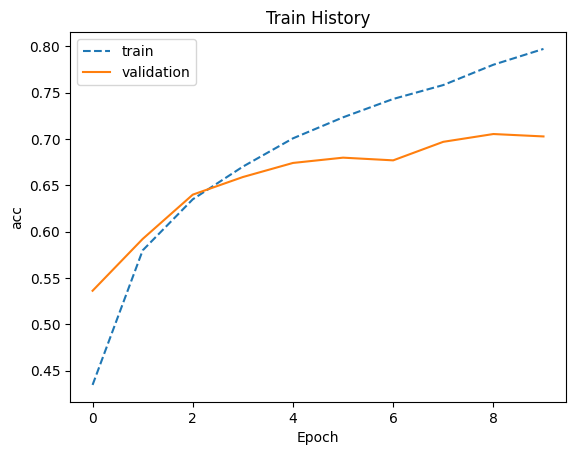

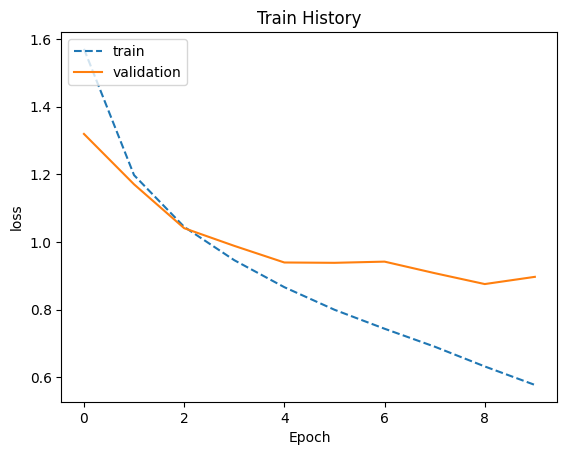

In [6]:
show_train_history(train_history, 'acc', 'val_acc')
show_train_history(train_history, 'loss', 'val_loss')

# 測試模型

In [8]:
scores = model.evaluate(X_test_normalize, y_test_onehot, verbose=2)
print('Test Accuracy:', scores[1])
print('Test Loss:', scores[0])

313/313 - 2s - 7ms/step - acc: 0.6951 - loss: 0.9067
Test Accuracy: 0.6951000094413757
Test Loss: 0.906685471534729


In [9]:
import tensorflow as tf
import numpy as np

probability = model.predict(X_test_normalize)
prediction = tf.argmax(probability, axis=-1).numpy()

# 查看前 10 筆預測結果
print(f"前 10 筆預測結果: {prediction[:10]}")
# 查看前 10 筆真實標籤
print(f"前 10 筆真實標籤: {y_test_label[:10]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
前 10 筆預測結果: [3 8 8 0 6 6 1 6 3 1]
前 10 筆真實標籤: [3 8 8 0 6 6 1 6 3 1]


# 查看預測結果

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

label_dict = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

def plot_images_labels_prediction(images, labels, prediction, idx, num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num > 25: num = 25
    for i in range(0, num):
        ax = plt.subplot(5, 5, i+1)
        ax.imshow(images[idx], cmap='binary')
        title = "label=" + str(label_dict[labels[idx]])
        if len(prediction) > 0:
            title += ", predict=" + str(label_dict[prediction[idx]])
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        idx += 1
    plt.show()

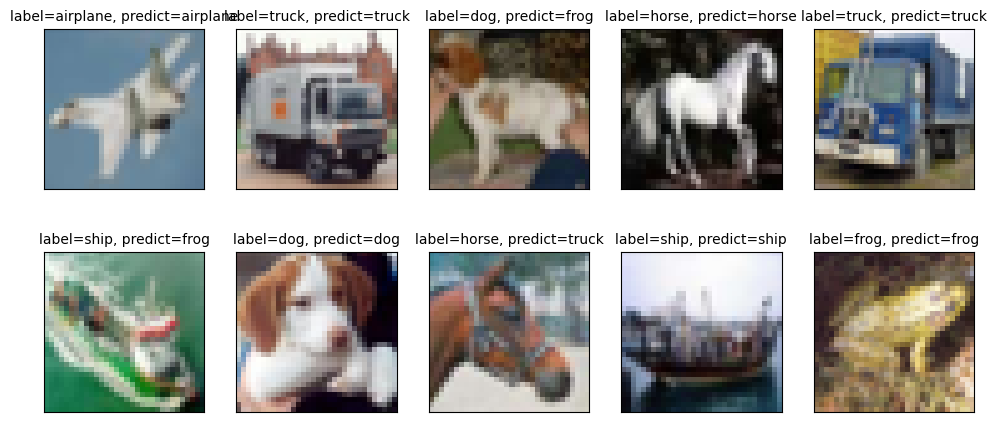

In [11]:
plot_images_labels_prediction(X_test_image, y_test_label, prediction, idx=10, num=10)

In [23]:
label_dict = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

def show_predicted_probability(images, labels, prediction, probability, idx):
    plt.figure(figsize=(1,1))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(images[idx], cmap='binary')
    plt.show()
    if len(labels) > 0: print('label:', label_dict[labels[idx]])
    if len(prediction) > 0: print('predict:', label_dict[prediction[idx]])
    for i in range(10):
        print('%-10s Probability:%9f' % (label_dict[i], probability[idx][i]))

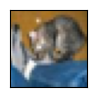

label: cat
predict: cat
airplane   Probability: 0.042003
automobile Probability: 0.000635
bird       Probability: 0.011662
cat        Probability: 0.609169
deer       Probability: 0.002830
dog        Probability: 0.114915
frog       Probability: 0.215047
horse      Probability: 0.001045
ship       Probability: 0.002605
truck      Probability: 0.000090


In [24]:
show_predicted_probability(X_test_image, y_test_label, prediction, probability ,0)

# 混淆矩陣

In [25]:
import pandas as pd

cm = pd.crosstab(index=y_test_label, columns=prediction, rownames=['label'], colnames=['predict'])
cm

predict,0,1,2,3,4,5,6,7,8,9
label,,,,,,,,,,
0,768,22,44,18,7,3,16,9,66,47
1,15,846,8,10,0,4,8,2,17,90
2,71,10,607,68,41,44,109,30,9,11
3,26,25,84,511,30,127,122,27,19,29
4,33,14,108,68,526,37,137,57,13,7
5,17,11,88,200,30,534,63,36,10,11
6,4,15,42,48,9,14,855,3,6,4
7,30,16,50,35,41,60,19,720,1,28
8,65,53,21,12,4,6,9,2,796,32


# heatmap顯示混淆矩陣

In [32]:
import numpy as np

cm_mat = cm.to_numpy()
cm_mat

array([[768,  22,  44,  18,   7,   3,  16,   9,  66,  47],
       [ 15, 846,   8,  10,   0,   4,   8,   2,  17,  90],
       [ 71,  10, 607,  68,  41,  44, 109,  30,   9,  11],
       [ 26,  25,  84, 511,  30, 127, 122,  27,  19,  29],
       [ 33,  14, 108,  68, 526,  37, 137,  57,  13,   7],
       [ 17,  11,  88, 200,  30, 534,  63,  36,  10,  11],
       [  4,  15,  42,  48,   9,  14, 855,   3,   6,   4],
       [ 30,  16,  50,  35,  41,  60,  19, 720,   1,  28],
       [ 65,  53,  21,  12,   4,   6,   9,   2, 796,  32],
       [ 28, 105,   9,  12,   2,   7,  16,  13,  20, 788]])

In [33]:
# 標準化處理
cm_norm = np.around(cm_mat.astype('float') / cm_mat.sum(axis=1)[:, np.newaxis], decimals=3)
cm_norm

array([[0.768, 0.022, 0.044, 0.018, 0.007, 0.003, 0.016, 0.009, 0.066,
        0.047],
       [0.015, 0.846, 0.008, 0.01 , 0.   , 0.004, 0.008, 0.002, 0.017,
        0.09 ],
       [0.071, 0.01 , 0.607, 0.068, 0.041, 0.044, 0.109, 0.03 , 0.009,
        0.011],
       [0.026, 0.025, 0.084, 0.511, 0.03 , 0.127, 0.122, 0.027, 0.019,
        0.029],
       [0.033, 0.014, 0.108, 0.068, 0.526, 0.037, 0.137, 0.057, 0.013,
        0.007],
       [0.017, 0.011, 0.088, 0.2  , 0.03 , 0.534, 0.063, 0.036, 0.01 ,
        0.011],
       [0.004, 0.015, 0.042, 0.048, 0.009, 0.014, 0.855, 0.003, 0.006,
        0.004],
       [0.03 , 0.016, 0.05 , 0.035, 0.041, 0.06 , 0.019, 0.72 , 0.001,
        0.028],
       [0.065, 0.053, 0.021, 0.012, 0.004, 0.006, 0.009, 0.002, 0.796,
        0.032],
       [0.028, 0.105, 0.009, 0.012, 0.002, 0.007, 0.016, 0.013, 0.02 ,
        0.788]])

In [35]:
# DataFrame顯示混淆矩陣
class_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
cm_df = pd.DataFrame(cm_norm, index=class_name, columns=class_name)
cm_df

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
airplane,0.768,0.022,0.044,0.018,0.007,0.003,0.016,0.009,0.066,0.047
automobile,0.015,0.846,0.008,0.010,0.000,0.004,0.008,0.002,0.017,0.090
bird,0.071,0.010,0.607,0.068,0.041,0.044,0.109,0.030,0.009,0.011
cat,0.026,0.025,0.084,0.511,0.030,0.127,0.122,0.027,0.019,0.029
deer,0.033,0.014,0.108,0.068,0.526,0.037,0.137,0.057,0.013,0.007
dog,0.017,0.011,0.088,0.200,0.030,0.534,0.063,0.036,0.010,0.011
frog,0.004,0.015,0.042,0.048,0.009,0.014,0.855,0.003,0.006,0.004
horse,0.030,0.016,0.050,0.035,0.041,0.060,0.019,0.720,0.001,0.028
ship,0.065,0.053,0.021,0.012,0.004,0.006,0.009,0.002,0.796,0.032
truck,0.028,0.105,0.009,0.012,0.002,0.007,0.016,0.013,0.020,0.788


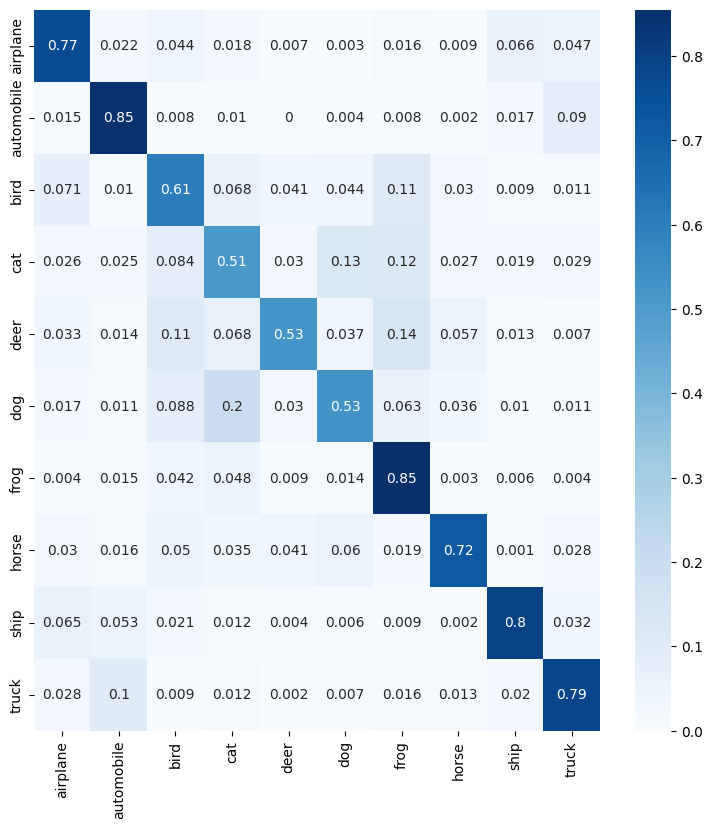

In [36]:
figure = plt.figure(figsize=(8, 8))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
sns.heatmap(cm_df, annot=True, cmap='Blues')
plt.show()

# 函數heatmap顯示混淆矩陣

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def plot_heatmap_confusion_matrix(cm_np, class_names):
    cm_np_norm = np.around(cm_np.astype('float') / cm_np.sum(axis=1)[:, np.newaxis], decimals=3)
    cm_df = pd.DataFrame(cm_np_norm, index=class_names, columns=class_names)
    figure = plt.figure(figsize=(10, 8))
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    sns.set(font_scale=1.2)
    sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='.3f')
    return figure

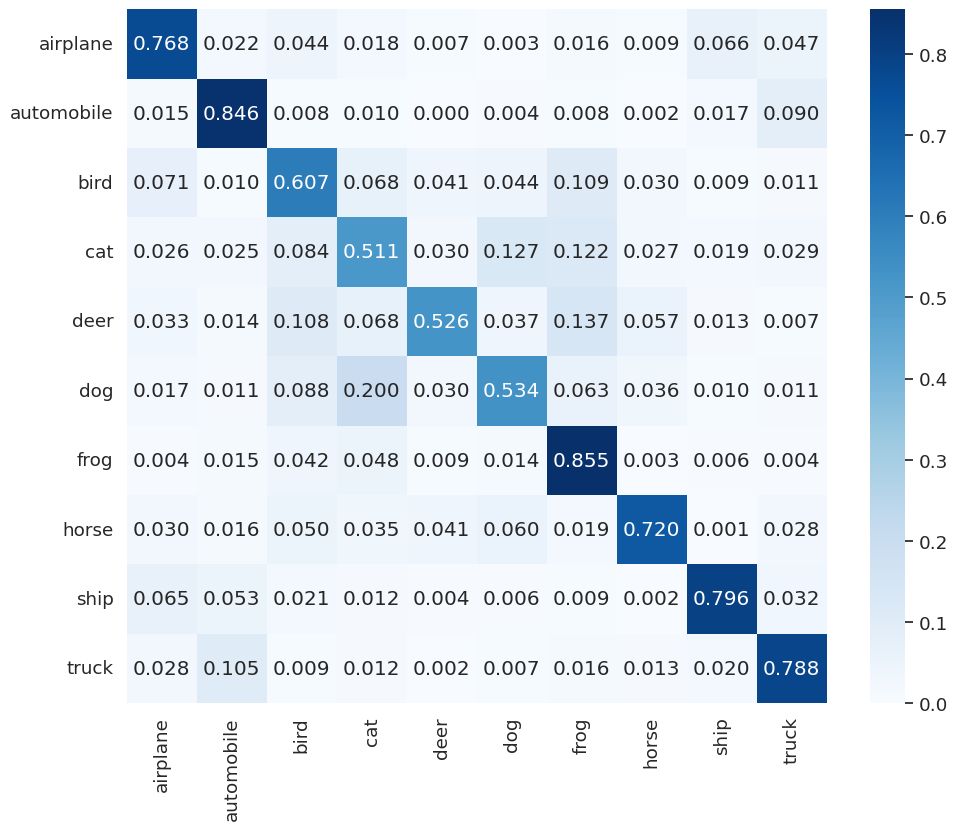

In [44]:
figure = plot_heatmap_confusion_matrix(cm.to_numpy(), class_names)